In [1]:
import sys
import os
import inspect, importlib
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

os.chdir('/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys') # seems to be the only real fix


print(sys.path)
print()
print(os.getcwd())

from lfp.lfp_analysis.LFP_collection import LFPCollection

print("\nLFP_collection package from:", inspect.getfile(LFPCollection))

['/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python310.zip', '/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python3.10', '/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python3.10/lib-dynload', '', '/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python3.10/site-packages', '/blue/npadillacoreano/t.heeps/rehouse_code/ephys_analysis']

/blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys


/blue/npadillacoreano/t.heeps/.conda/envs/lfp_export_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



LFP_collection package from: /blue/npadillacoreano/t.heeps/rehouse_code/diff_fam_social_memory_ephys/lfp/lfp_analysis/LFP_collection.py


In [2]:
import lfp.lfp_analysis.LFP_collection as LFP_collection_module
importlib.reload(LFP_collection_module)
from lfp.lfp_analysis.LFP_collection import LFPCollection

In [3]:
# Path to your saved JSON
json_path = "/home/t.heeps/blue_npadillacoreano/npadillacoreano/share/rehouse_data/lfp_collections/aligned_lfpcollection_44_41.json"

# Load the collection
lfp_collection = LFPCollection.load_collection(json_path)

# Confirm successful load
print(f"✅ Loaded {len(lfp_collection.recordings)} recordings")
print("Brain regions:", list(lfp_collection.brain_region_dict.keys()))

✅ Loaded 4 recordings
Brain regions: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']


In [4]:
lfp_collection.preprocess()

  0%|          | 0/4 [00:00<?, ?it/s]

processing 44_rehouse_d0_merged.rec


 25%|██▌       | 1/4 [00:00<00:02,  1.38it/s]

RMS Traces calculated
processing 41_rehouse_d0_merged.rec


 50%|█████     | 2/4 [00:01<00:01,  1.46it/s]

RMS Traces calculated
processing 41_rehouse_d7_merged.rec


 75%|███████▌  | 3/4 [00:02<00:00,  1.41it/s]

RMS Traces calculated
processing 44_rehouse_d7_merged.rec


100%|██████████| 4/4 [00:02<00:00,  1.43it/s]

RMS Traces calculated


In [5]:
lfp_collection.calculate_coherence()

 25%|██▌       | 1/4 [00:07<00:21,  7.15s/it]

Coherence calcualatd


 50%|█████     | 2/4 [00:16<00:16,  8.41s/it]

Coherence calcualatd


 75%|███████▌  | 3/4 [00:26<00:08,  8.95s/it]

Coherence calcualatd


100%|██████████| 4/4 [00:35<00:00,  8.86s/it]

Coherence calcualatd


In [6]:
for rec in lfp_collection.recordings:
    print(f"Recording: {rec.name} (Subject: {rec.subject}) — Regions: {list(rec.brain_region_dict.keys())}")


Recording: 44_rehouse_d0_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 41_rehouse_d0_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 41_rehouse_d7_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 44_rehouse_d7_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']


# Change baseline to first 10 minutes ! !! !


### Shape of Coherence:
coh.shape → (T, F, R, R):

T: time bins (based on window + step)

F: frequencies (based on multitaper settings)

R: brain regions (length of brain_region_dict)

In [7]:
d0_44_coh = lfp_collection.recordings[0].coherence
print(d0_44_coh.shape)

(3601, 500, 5, 5)


## Coherence now made | Loading behaviors for analysis

In [8]:
rec.event_dict['sniffing object'] # in ms

array([[ 609782.5 ,  611514.85],
       [ 612069.2 ,  612692.85],
       [ 616919.75,  617751.25],
       [ 621562.4 ,  622601.8 ],
       [ 637153.4 ,  637430.6 ],
       [ 657387.1 ,  661406.15],
       [ 674017.55,  677967.3 ],
       [ 679491.75,  680184.65],
       [ 711643.9 ,  712336.85],
       [ 752111.3 ,  753358.6 ],
       [ 797914.3 ,  798191.45],
       [ 812812.4 ,  813921.1 ],
       [ 820781.15,  822097.7 ],
       [ 838312.4 ,  838451.  ],
       [ 871226.8 ,  871573.25],
       [ 940312.4 ,  941351.8 ],
       [ 944608.6 ,  946133.05],
       [ 949389.85,  950013.5 ],
       [ 973781.15,  974058.3 ],
       [1017297.45, 1017574.6 ],
       [1056032.5 , 1056240.4 ],
       [1226259.8 , 1226979.5 ]])

In [9]:
rec = lfp_collection.recordings[0]
print(rec.name)
print(rec.event_dict.keys())  # List of behavior types (e.g., 'sniffing', 'fighting', etc.)

44_rehouse_d0_merged.rec
dict_keys(['anogenital sniffing', 'facial sniffing', 'mice back in', 'mice taken out', 'sniffing object'])


### Creating time vector to allow us to put an event behavior mask over coherence

### We have one value per time window .shape[0], but we don't seem to have a timestamp attached to those windows, we create it here with the timestep taking the time at the center of each window

In [10]:
rec.timestep

np.float64(0.5)

#### timestep is 0.5 seconds long

In [11]:
# multiplying # of samples by timesteps, where each sample = 1 timestep in time
# here that's 3600 * (0.5 * 1000) = 1800000 seconds, vector length 3601 each 500 ms, with 0.0 to start causing the 3601.
def create_time_vector(rec):
    T = rec.coherence.shape[0]
    step_ms = rec.timestep * 1000.0  # 0.5 s → 500 ms
    tvec = np.arange(T) * step_ms    # now in ms
    return tvec

In [12]:
tvec = create_time_vector(rec)
print("tvec shape:", tvec.shape)
print("Start:", tvec[0], "End:", tvec[-1])


tvec shape: (3601,)
Start: 0.0 End: 1800000.0


In [13]:
def make_event_mask(tvec, event_ranges):
    """
    Create a boolean mask over `tvec` for all event time ranges.
    """
    mask = np.zeros_like(tvec, dtype=bool)
    for start, stop in event_ranges:
        mask |= (tvec >= start) & (tvec <= stop)
        
    return mask


In [14]:
for rec in lfp_collection.recordings:
    rec.tvec = create_time_vector(rec)
    print(rec.tvec)

[0.0000e+00 5.0000e+02 1.0000e+03 ... 1.7990e+06 1.7995e+06 1.8000e+06]
[0.0000e+00 5.0000e+02 1.0000e+03 ... 1.7990e+06 1.7995e+06 1.8000e+06]
[0.0000e+00 5.0000e+02 1.0000e+03 ... 1.7985e+06 1.7990e+06 1.7995e+06]
[0.0000e+00 5.0000e+02 1.0000e+03 ... 1.7980e+06 1.7985e+06 1.7990e+06]


In [15]:
print(f"{rec.name}:")
print(f"  - first_timestamp: {rec.first_timestamp}")
print(f"  - timestep: {rec.timestep}")
print(f"  - coherence.shape[0] = {rec.coherence.shape[0]}")
print(f"  - tvec[0:5] = {tvec[:5]}")
print(f"  - tvec[-5:] = {tvec[-5:]}")


44_rehouse_d7_merged.rec:
  - first_timestamp: 1834892
  - timestep: 0.5
  - coherence.shape[0] = 3599
  - tvec[0:5] = [   0.  500. 1000. 1500. 2000.]
  - tvec[-5:] = [1798000. 1798500. 1799000. 1799500. 1800000.]


In [16]:
print(rec.name)

44_rehouse_d7_merged.rec


### Coherence during event with both low fam and high fam plotted for both subjects

In [17]:
def plot_event_coherence(
    lfp_collection, events='sniffing object', region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    if isinstance(events, str):
        events = [events]  # convert to list if single string

    curves = []

    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        # Combine masks for all requested events
        tvec = create_time_vector(rec)
        combined_mask = np.zeros_like(tvec, dtype=bool)
        valid = False

        for event in events:
            if event in rec.event_dict:
                mask = make_event_mask(tvec, rec.event_dict[event])
                combined_mask |= mask  # logical OR
                valid = True

        if not valid or not np.any(combined_mask):
            continue

        coh_event = rec.coherence[combined_mask]  # (T_event, F, R, R)
        avg_coh = np.nanmean(coh_event, axis=0)  # (F, R, R)

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]
        F, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            continue

        coh_curve = avg_coh[:, from_idx, to_idx]
        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]

        if 'd0' in rec.name.lower():
            fam = 'low fam'
        elif 'd7' in rec.name.lower():
            fam = 'high fam'
        else:
            fam = 'unknown fam'

        label = f"subj {subj} - {fam}"
        curves.append((label, freqs_plot, coh_plot, subj, fam, rec.name))

    if not curves:
        print(f"⚠️ No valid data to plot for events {events} and region {region_from} - {region_to}")
        return

    # Define hardcoded RGB colors (0–1 scale)
    low_fam_color = (1/255, 138/255, 126/255)   # d0
    high_fam_color = (100/255, 5/255, 49/255)   # d7

    plt.figure(figsize=(5.5, 5.5))
    for label, freqs, coh, subj, fam, rec_name in curves:
        if fam == 'low fam':
            color = low_fam_color
            linestyle = '-'
        elif fam == 'high fam':
            color = high_fam_color
            linestyle = '--'
        else:
            color = 'gray'
            linestyle = ':'

        plt.plot(freqs, coh, label=label, linewidth=2.5, linestyle=linestyle, color=color)
        print(f"➡️  {rec_name}: Subject={subj}, Day={fam}, Freq Shape={freqs.shape}, Coherence Mean={np.nanmean(coh):.3f}")


    event_str = ', '.join(events)
    plt.title(title if title else f"{region_from} - {region_to} Coherence during {event_str}", fontsize=18)
    plt.xlabel("Frequency (Hz)", fontsize=14)
    plt.ylabel("Coherence", fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(False)
    plt.ylim(0.35, 1)
    plt.tight_layout()
    plt.tick_params(axis='both', which='major', labelsize=14)

    if save_path:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}_{'_'.join(e.replace(' ', '_') for e in events)}.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


/scratch/local/14692585/ipykernel_3692295/453750533.py:30: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(coh_event, axis=0)  # (F, R, R)


➡️  44_rehouse_d0_merged.rec: Subject=44, Day=low fam, Freq Shape=(101,), Coherence Mean=0.607
➡️  41_rehouse_d0_merged.rec: Subject=41, Day=low fam, Freq Shape=(101,), Coherence Mean=0.565
➡️  41_rehouse_d7_merged.rec: Subject=41, Day=high fam, Freq Shape=(101,), Coherence Mean=0.567
➡️  44_rehouse_d7_merged.rec: Subject=44, Day=high fam, Freq Shape=(101,), Coherence Mean=0.636


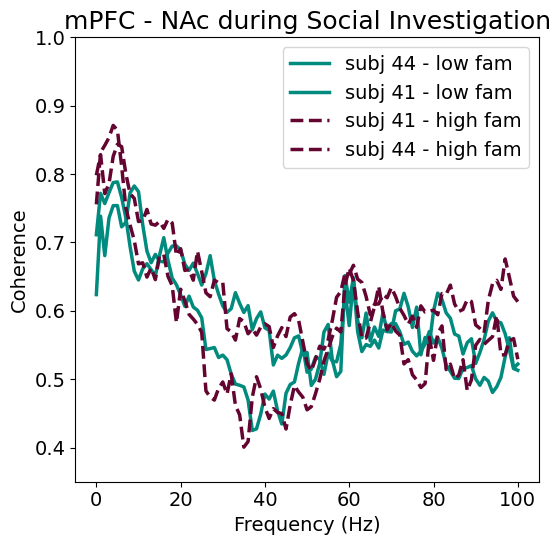

➡️  44_rehouse_d0_merged.rec: Subject=44, Day=low fam, Freq Shape=(101,), Coherence Mean=0.520
➡️  41_rehouse_d0_merged.rec: Subject=41, Day=low fam, Freq Shape=(101,), Coherence Mean=0.496
➡️  41_rehouse_d7_merged.rec: Subject=41, Day=high fam, Freq Shape=(101,), Coherence Mean=0.491
➡️  44_rehouse_d7_merged.rec: Subject=44, Day=high fam, Freq Shape=(101,), Coherence Mean=0.540


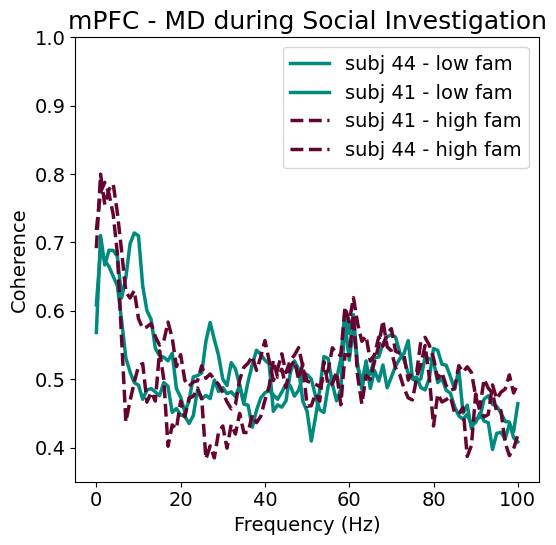

In [18]:
plot_event_coherence(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during Social Investigation",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/aligned_plots/'

)
plot_event_coherence(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during Social Investigation",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/aligned_plots/'

)


### Coherence during events, one plot per subject and brain regions

In [20]:
def plot_event_coherence_avg_fam(
    lfp_collection, events='sniffing object', region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    if isinstance(events, str):
        events = [events]

    # Gather all coherence curves for each fam across subjects
    subj_data = defaultdict(list)
    freqs_plot = None  # For use in plotting

    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        tvec = create_time_vector(rec)
        combined_mask = np.zeros_like(tvec, dtype=bool)
        valid = False

        for event in events:
            if event in rec.event_dict:
                mask = make_event_mask(tvec, rec.event_dict[event])
                combined_mask |= mask
                valid = True

        if not valid or not np.any(combined_mask):
            continue

        coh_event = rec.coherence[combined_mask]  # (T_event, F, R, R)
        avg_coh = np.nanmean(coh_event, axis=0)   # (F, R, R)

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]
        F, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            continue

        coh_curve = avg_coh[:, from_idx, to_idx]
        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        # Figure out familiarity condition
        if 'd0' in rec.name.lower():
            fam = 'low fam'
        elif 'd7' in rec.name.lower():
            fam = 'high fam'
        else:
            fam = 'unknown fam'

        subj_data[fam].append(coh_plot)

    if not subj_data:
        print(f"⚠️ No valid data to plot for events {events} and region {region_from} - {region_to}")
        return

    # --- Define colors ---
    low_fam_color = (1/255, 138/255, 126/255)
    high_fam_color = (100/255, 5/255, 49/255)

    plt.figure(figsize=(5.5, 5.5))

    # --- Plot two lines: avg low fam, avg high fam ---
    for fam, curves in subj_data.items():
        coh_array = np.stack(curves, axis=0)  # (N_total_rec, F)
        mean_coh = np.nanmean(coh_array, axis=0)

        if fam == 'low fam':
            color = low_fam_color
            linestyle = '-'
        elif fam == 'high fam':
            color = high_fam_color
            linestyle = '-'
        else:
            color = 'gray'
            linestyle = ':'

        label = f"{fam}"
        plt.plot(freqs_plot, mean_coh, label=label, linewidth=2.5, linestyle=linestyle, color=color)
        print(f"📊 Averaged {fam}: {coh_array.shape[0]} recordings, Mean coherence = {np.nanmean(mean_coh):.3f}")
        

    # --- Pretty up plot ---
    event_str = ', '.join(events)
    plt.title(title if title else f"{region_from} - {region_to} Coherence during {event_str}", fontsize=18)
    plt.xlabel("Frequency (Hz)", fontsize=14)
    plt.ylabel("Coherence", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(False)
    plt.ylim(0.35, 1)
    plt.tight_layout()
    plt.tick_params(axis='both', which='major', labelsize=14)

    # --- Save or show ---
    if save_path:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}_avgfam_{'_'.join(e.replace(' ', '_') for e in events)}.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()
        
    


/scratch/local/14692585/ipykernel_3692295/3365347403.py:31: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(coh_event, axis=0)   # (F, R, R)


📊 Averaged low fam: 2 recordings, Mean coherence = 0.586
📊 Averaged high fam: 2 recordings, Mean coherence = 0.602


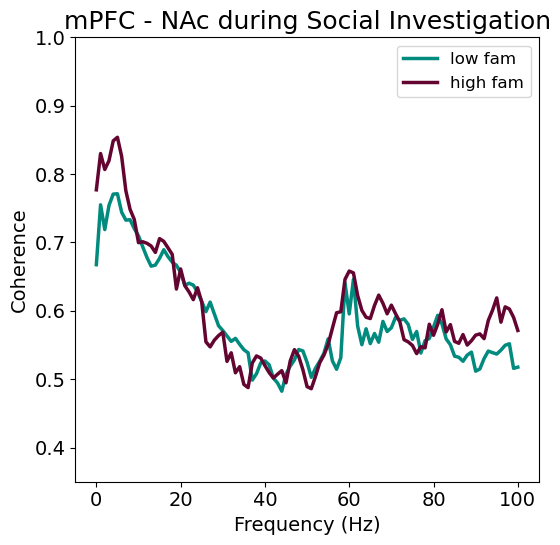

📊 Averaged low fam: 2 recordings, Mean coherence = 0.508
📊 Averaged high fam: 2 recordings, Mean coherence = 0.516


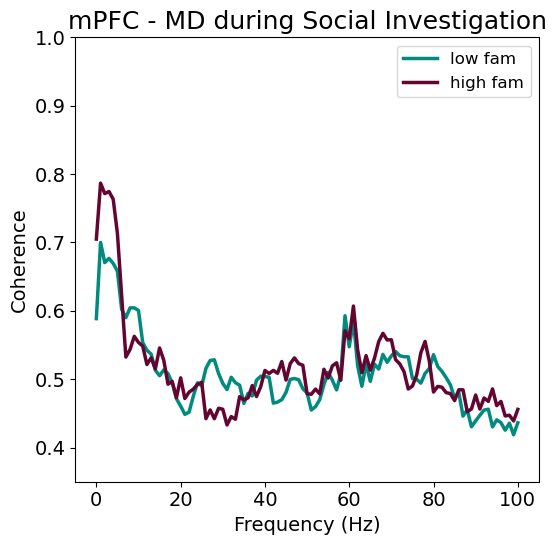

In [21]:
plot_event_coherence_avg_fam(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during Social Investigation",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)
plot_event_coherence_avg_fam(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during Social Investigation",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)


/scratch/local/14692585/ipykernel_3692295/3365347403.py:31: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(coh_event, axis=0)   # (F, R, R)


📊 Averaged low fam: 2 recordings, Mean coherence = 0.581
📊 Averaged high fam: 2 recordings, Mean coherence = 0.598


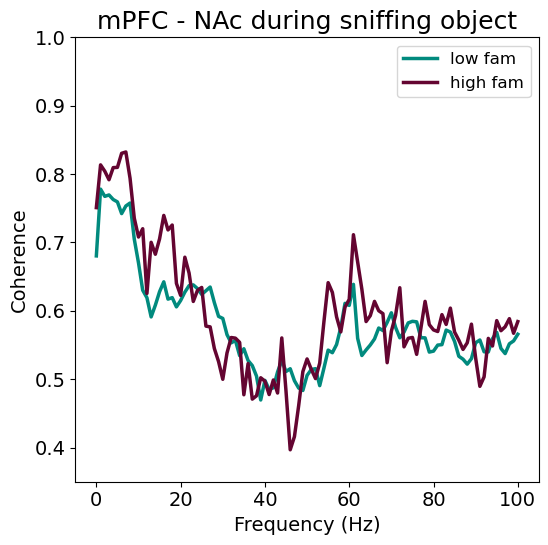

📊 Averaged low fam: 2 recordings, Mean coherence = 0.502
📊 Averaged high fam: 2 recordings, Mean coherence = 0.497


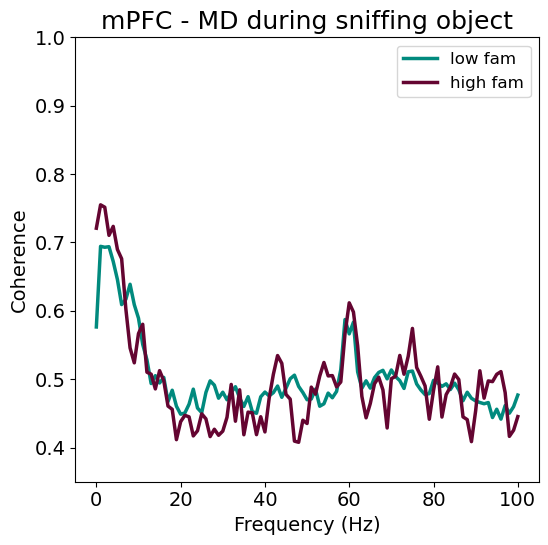

In [22]:
plot_event_coherence_avg_fam(
    lfp_collection,
    events=['sniffing object'],
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during sniffing object",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)

plot_event_coherence_avg_fam(
    lfp_collection,
    events=['sniffing object'],
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during sniffing object",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)


In [23]:
def create_baseline_events(rec, baseline_label='baseline'):
    """
    Create baseline events that fill all time periods not covered by existing events.
    
    Parameters:
    -----------
    rec : recording object
        Recording with event_dict containing event times in ms and tvec
    baseline_label : str
        Label for the baseline events (default: 'baseline')
    
    Returns:
    --------
    numpy.ndarray
        Array of [start, end] times for baseline periods in ms
    """
    # Get recording boundaries
    recording_start = rec.tvec[0]
    recording_end = rec.tvec[-1]
    
    # Get all existing events and flatten into a list of intervals
    all_events = []
    for event_type, events in rec.event_dict.items():
        if event_type != baseline_label and len(events) > 0:  # Don't include baseline in baseline
            all_events.extend(events)
    
    if len(all_events) == 0:
        # No events exist, entire recording is baseline
        return np.array([[recording_start, recording_end]])
    
    # Sort all events by start time
    all_events = np.array(all_events)
    all_events = all_events[all_events[:, 0].argsort()]
    
    # Merge overlapping events
    merged_events = []
    current_start, current_end = all_events[0]
    
    for start, end in all_events[1:]:
        if start <= current_end:
            # Overlapping or adjacent, extend current event
            current_end = max(current_end, end)
        else:
            # Gap found, save current and start new
            merged_events.append([current_start, current_end])
            current_start, current_end = start, end
    
    # Add the last event
    merged_events.append([current_start, current_end])
    merged_events = np.array(merged_events)
    
    # Create baseline events in the gaps
    baseline_events = []
    
    # Baseline before first event
    if merged_events[0, 0] > recording_start:
        baseline_events.append([recording_start, merged_events[0, 0]])
    
    # Baseline between events
    for i in range(len(merged_events) - 1):
        gap_start = merged_events[i, 1]
        gap_end = merged_events[i + 1, 0]
        if gap_end > gap_start:
            baseline_events.append([gap_start, gap_end])
    
    # Baseline after last event
    if recording_end > merged_events[-1, 1]:
        baseline_events.append([merged_events[-1, 1], recording_end])
    
    return np.array(baseline_events) if baseline_events else np.array([]).reshape(0, 2)


# Add baseline events to all recordings
for rec in lfp_collection.recordings:
    if not hasattr(rec, 'tvec'):
        rec.tvec = create_time_vector(rec)
    rec.event_dict['baseline'] = create_baseline_events(rec)
    
    print(f"\n{rec.name}")
    baseline_events = rec.event_dict['baseline']
    if len(baseline_events) > 0:
        total_baseline_time = np.sum(baseline_events[:, 1] - baseline_events[:, 0])
        print(f"  Baseline periods: {len(baseline_events)}")
        print(f"  Total baseline time: {total_baseline_time / 1000:.1f}s ({total_baseline_time / rec.tvec[-1] * 100:.1f}%)")


44_rehouse_d0_merged.rec
  Baseline periods: 94
  Total baseline time: 1682.9s (93.5%)

41_rehouse_d0_merged.rec
  Baseline periods: 87
  Total baseline time: 1573.8s (87.4%)

41_rehouse_d7_merged.rec
  Baseline periods: 57
  Total baseline time: 1744.0s (96.9%)

44_rehouse_d7_merged.rec
  Baseline periods: 54
  Total baseline time: 1693.6s (94.1%)


/scratch/local/14692585/ipykernel_3692295/3365347403.py:31: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(coh_event, axis=0)   # (F, R, R)


📊 Averaged low fam: 2 recordings, Mean coherence = 0.582
📊 Averaged high fam: 2 recordings, Mean coherence = 0.602


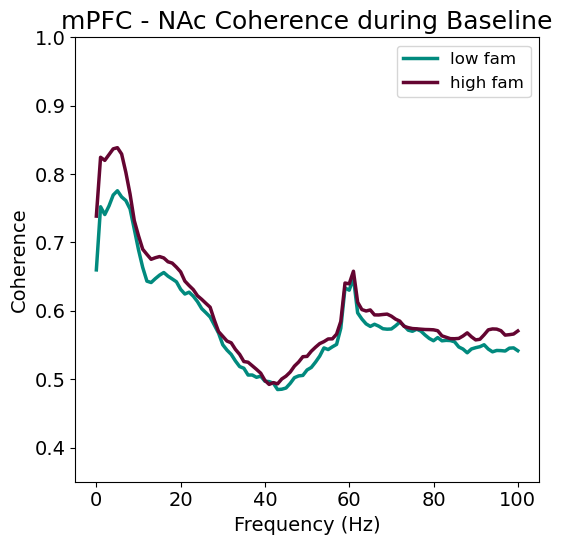

📊 Averaged low fam: 2 recordings, Mean coherence = 0.586
📊 Averaged high fam: 2 recordings, Mean coherence = 0.602


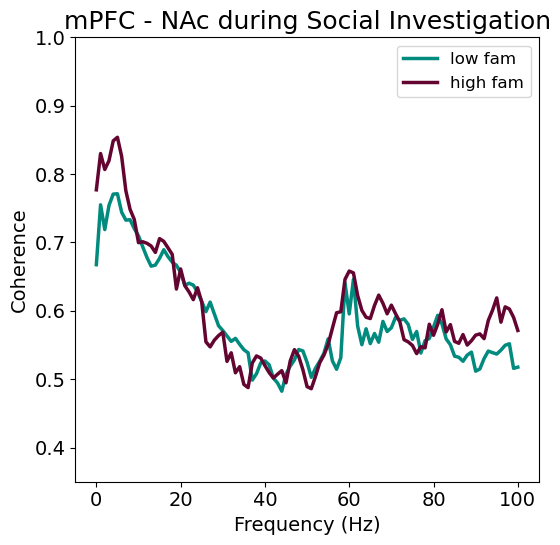

📊 Averaged low fam: 2 recordings, Mean coherence = 0.495
📊 Averaged high fam: 2 recordings, Mean coherence = 0.505


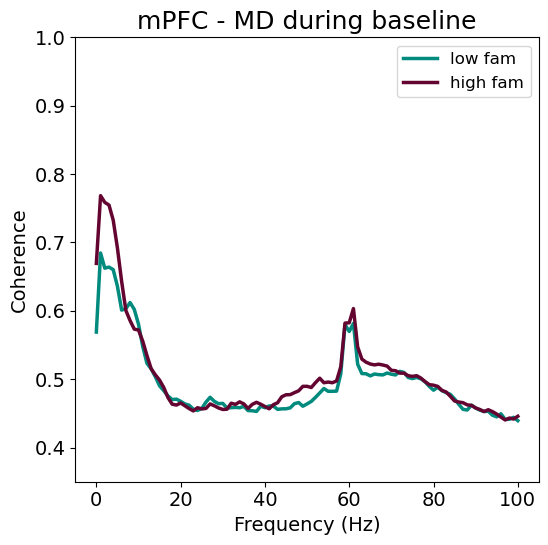

📊 Averaged low fam: 2 recordings, Mean coherence = 0.508
📊 Averaged high fam: 2 recordings, Mean coherence = 0.516


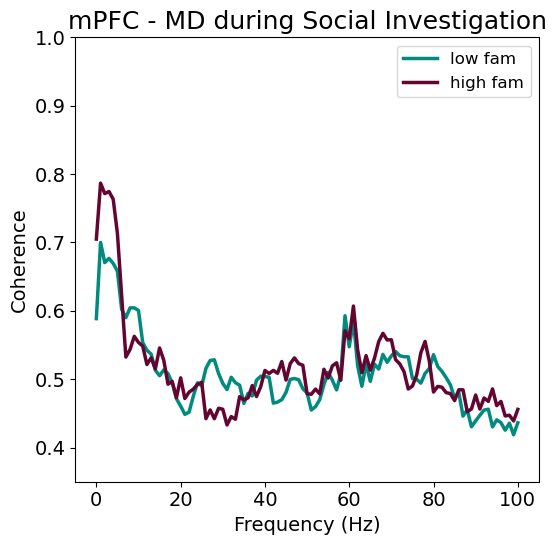

In [25]:
# Plot coherence during baseline periods
plot_event_coherence_avg_fam(
    lfp_collection, 
    events='baseline',  # <-- Just use 'baseline' as the event!
    region_from='mPFC', 
    region_to='NAc', 
    freq_limit=100,
    title='mPFC - NAc Coherence during Baseline'
)

plot_event_coherence_avg_fam(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='NAc',
    title="mPFC - NAc during Social Investigation",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)

# MPFC-MD

plot_event_coherence_avg_fam(
    lfp_collection,
    events=['baseline'],
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during baseline",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)

plot_event_coherence_avg_fam(
    lfp_collection,
    events=['facial sniffing', 'anogenital sniffing'],
    region_from='mPFC',
    region_to='MD',
    title="mPFC - MD during Social Investigation",
    # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'

)


### Directionality plots for ***mpfc*** -> ***nac*** and ***mpfc*** -> ***md***

In [28]:
def coh_plot(rec, freqs, mpfc_to_nac, mpfc_to_md, save_dir=None):
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, mpfc_to_nac, label='mPFC → NAc', color='blue')
    plt.plot(freqs, mpfc_to_md, label='mPFC → MD', color='green')
    plt.title(f"Average Coherence Directionality — {rec.name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Coherence")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if save_dir is not None:
        # Safe file name
        fname = f"coh_{rec.name.replace('.rec','')}.png"
        plt.savefig(os.path.join(save_dir, fname))
        plt.close()
    else:
        plt.show()

In [29]:
# Pick a recording to visualize
d0_44 = lfp_collection.recordings[0]

In [30]:
# Get region indices
region_dict = d0_44.brain_region_dict
mpfc_idx = region_dict['mPFC']
nac_idx = region_dict['NAc']
md_idx = region_dict['MD']

### Get Average, spectra for each direction, slice freqs 

In [31]:
# Average over time (T axis)
avg_coh = np.nanmean(d0_44.coherence, axis=0)  # shape: (F, R, R)

# Get coherence spectra for each direction
mpfc_to_nac = avg_coh[:, mpfc_idx, nac_idx]
mpfc_to_md = avg_coh[:, mpfc_idx, md_idx]

# Slice to 0–100 Hz only
freqs = d0_44.frequencies  # full frequency vector, e.g., 0–500 Hz
freq_mask = freqs <= 100
freqs = freqs[freq_mask]
mpfc_to_nac = mpfc_to_nac[freq_mask]
mpfc_to_md = mpfc_to_md[freq_mask]

/scratch/local/14692585/ipykernel_2567011/2152753303.py:2: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(d0_44.coherence, axis=0)  # shape: (F, R, R)


In [32]:
print("avg_coh shape:", avg_coh.shape)
print("brain regions in recording:", rec.brain_region_dict)
print("mpfc_idx:", mpfc_idx, "nac_idx:", nac_idx, "bla_idx:", rec.brain_region_dict.get("BLA", "not found"))


avg_coh shape: (500, 5, 5)
brain regions in recording: bidict({'BLA': 3, 'MD': 2, 'NAc': 1, 'mPFC': 0, 'vHPC': 4})
mpfc_idx: 0 nac_idx: 1 bla_idx: 3


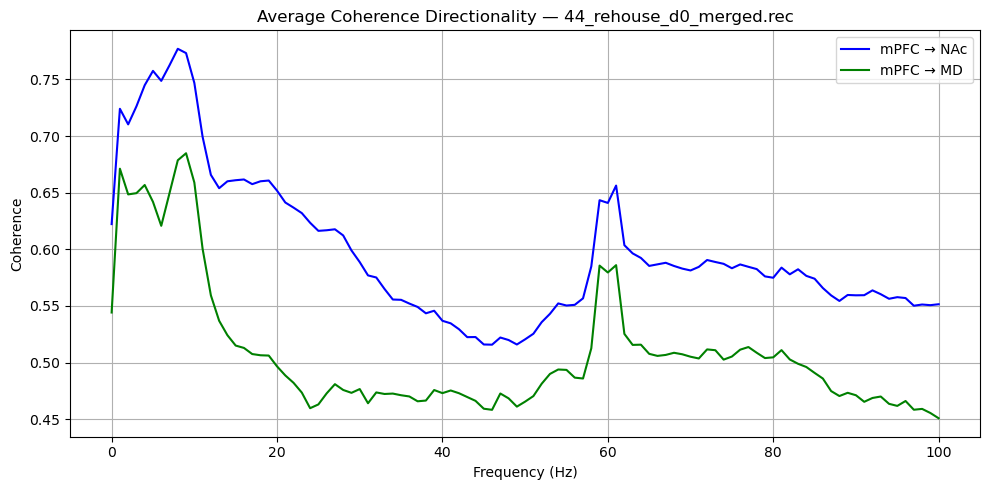

In [33]:
# Plot
coh_plot(d0_44, freqs, mpfc_to_nac, mpfc_to_md)

### Plots of 4.1 and 4.4 coherence directionality mpfc -> nac and mpfc -> MD

Processing 44_rehouse_d0_merged.rec


/scratch/local/14692585/ipykernel_2567011/355648638.py:14: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)


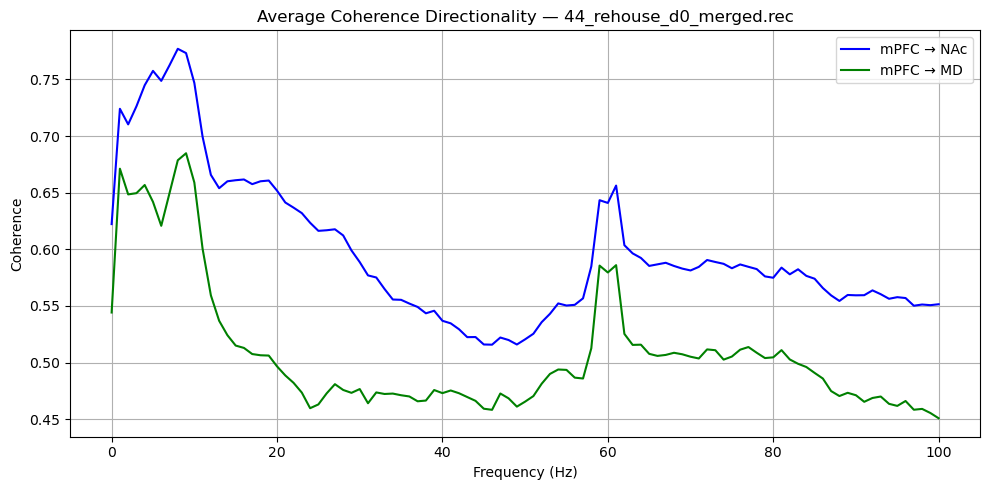

Processing 41_rehouse_d0_merged.rec


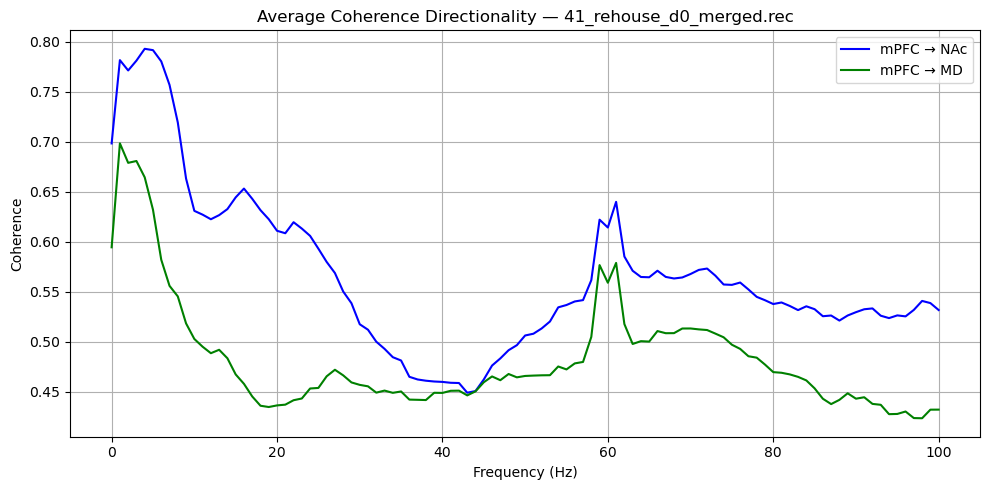

Processing 41_rehouse_d7_merged.rec


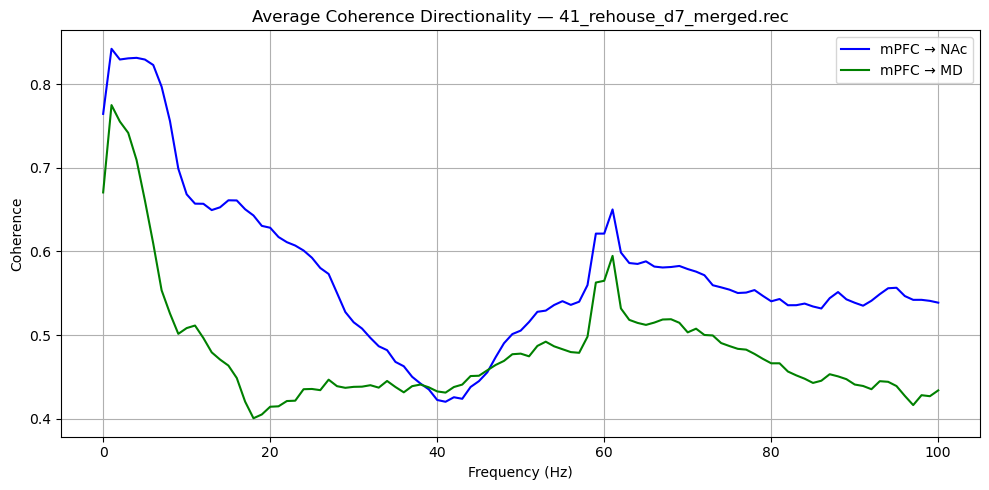

Processing 44_rehouse_d7_merged.rec


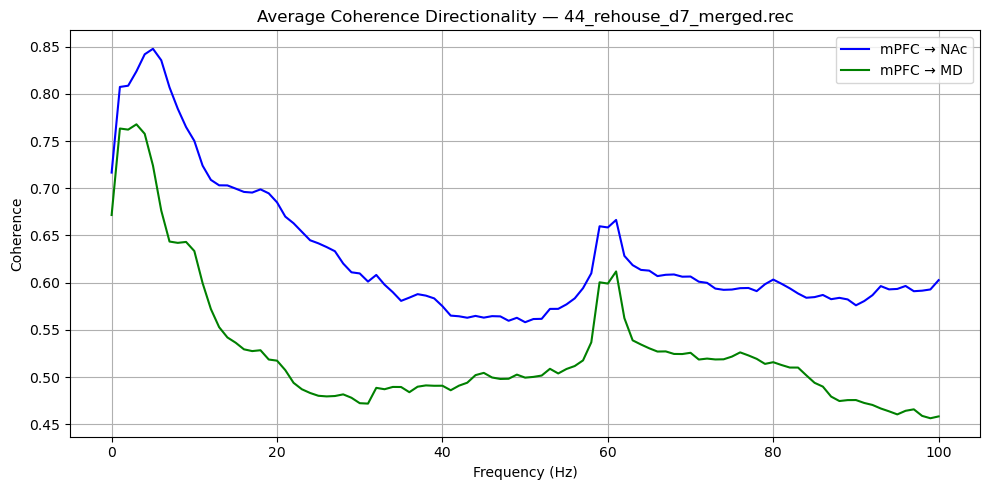

In [34]:
for rec in lfp_collection.recordings:
    print(f"Processing {rec.name}")
    region_dict = rec.brain_region_dict

    # Skip if any region is missing (shouldn't happen with your recordings)
    if not all(region in region_dict for region in ['mPFC', 'NAc', 'MD']):
        print(f"Skipping {rec.name}: required regions not found.")
        continue

    mpfc_idx = region_dict['mPFC']
    nac_idx = region_dict['NAc']
    md_idx = region_dict['MD']

    avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
    mpfc_to_nac = avg_coh[:, mpfc_idx, nac_idx]
    mpfc_to_md = avg_coh[:, mpfc_idx, md_idx]

    # Frequency restriction
    freqs = rec.frequencies
    freq_mask = freqs <= 100
    freqs_plot = freqs[freq_mask]
    mpfc_to_nac_plot = mpfc_to_nac[freq_mask]
    mpfc_to_md_plot = mpfc_to_md[freq_mask]

    # Plot (and/or save)
    coh_plot(
        rec, 
        freqs_plot, 
        mpfc_to_nac_plot, 
        mpfc_to_md_plot,
        # save_dir='/home/t.heeps/blue_npadillacoreano/rehouse_code/coherence_plots/plots',
    )

/scratch/local/14225831/ipykernel_3256897/3628726135.py:15: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)


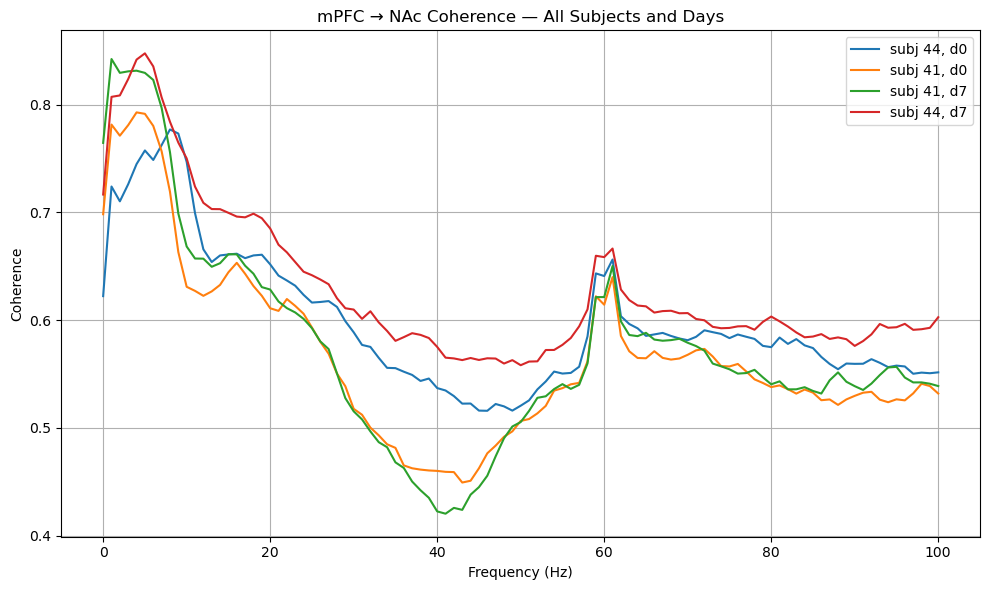

In [107]:
# Collect all mPFC-NAc curves for each (subject, day)
curves = []  # Each item: (label, freqs, coherence)

for rec in lfp_collection.recordings:
    region_dict = rec.brain_region_dict
    if not all(region in region_dict for region in ['mPFC', 'NAc']):
        continue

    # Subject and day — adjust as needed based on your actual attributes
    subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]
    day = 'd0' if 'd0' in rec.name else 'd7' if 'd7' in rec.name else 'UNK'

    mpfc_idx = region_dict['mPFC']
    nac_idx = region_dict['NAc']
    avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
    mpfc_to_nac = avg_coh[:, mpfc_idx, nac_idx]

    freqs = rec.frequencies
    freq_mask = freqs <= 100
    freqs_plot = freqs[freq_mask]
    mpfc_to_nac_plot = mpfc_to_nac[freq_mask]

    label = f"subj {subj}, {day}"
    curves.append((label, freqs_plot, mpfc_to_nac_plot))

# Plot all on one figure
plt.figure(figsize=(10, 6))
for label, freqs, coh in curves:
    plt.plot(freqs, coh, label=label)
plt.title("mPFC → NAc Coherence — All Subjects and Days")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Optionally save:
# plt.savefig('mpfc_nac_all_subjects_days.png')
# plt.close()


In [108]:
for rec in lfp_collection.recordings:
    print(f"Recording: {rec.name} (Subject: {rec.subject}) — Regions: {list(rec.brain_region_dict.keys())}")


Recording: 44_rehouse_d0_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 41_rehouse_d0_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 41_rehouse_d7_merged.rec (Subject: 41) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
Recording: 44_rehouse_d7_merged.rec (Subject: 44) — Regions: ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']


In [109]:
print("🔍 Verifying brain region integrity for each recording...\n")
for rec in lfp_collection.recordings:
    region_dict = rec.brain_region_dict
    region_names = list(region_dict.keys())

    coh_shape = rec.coherence.shape  # (T, F, R, R)
    T, F, R, _ = coh_shape

    # Reverse mapping: index to region (e.g., 0 → 'mPFC')
    reverse_map = {v: k for k, v in region_dict.items()}
    region_list_from_indices = [reverse_map.get(i, 'MISSING') for i in range(R)]

    print(f"📁 {rec.name} (Subject: {rec.subject})")
    print(f"  - Regions in dict:      {region_names}")
    print(f"  - Coherence shape:      {coh_shape}")
    print(f"  - Region count (R):     {R}")
    print(f"  - Regions by index map: {region_list_from_indices}")
    print(f"  - Missing regions:      {[r for r in ['mPFC','NAc','MD','vHPC','BLA'] if r not in region_names]}")
    print()


🔍 Verifying brain region integrity for each recording...

📁 44_rehouse_d0_merged.rec (Subject: 44)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3601, 500, 5, 5)
  - Region count (R):     5
  - Regions by index map: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']
  - Missing regions:      []

📁 41_rehouse_d0_merged.rec (Subject: 41)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3601, 500, 5, 5)
  - Region count (R):     5
  - Regions by index map: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']
  - Missing regions:      []

📁 41_rehouse_d7_merged.rec (Subject: 41)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3600, 500, 5, 5)
  - Region count (R):     5
  - Regions by index map: ['mPFC', 'NAc', 'MD', 'BLA', 'vHPC']
  - Missing regions:      []

📁 44_rehouse_d7_merged.rec (Subject: 44)
  - Regions in dict:      ['BLA', 'MD', 'NAc', 'mPFC', 'vHPC']
  - Coherence shape:      (3599

In [110]:
for recs in lfp_collection.recordings:
    print(f"{recs.name}, {recs.event_dict.keys()}")

44_rehouse_d0_merged.rec, dict_keys(['anogenital sniffing', 'chasing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object'])
41_rehouse_d0_merged.rec, dict_keys(['anogenital sniffing', 'facial sniffing', 'mice back in', 'mice taken out', 'sniffing object'])
41_rehouse_d7_merged.rec, dict_keys(['anogenital sniffing', 'chasing', 'facial sniffing', 'mice back in', 'mice taken out', 'sniffing object'])
44_rehouse_d7_merged.rec, dict_keys(['anogenital sniffing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object'])


### Plotting d0 and d7 rec together comparing coherence difference

/scratch/local/14225831/ipykernel_3256897/3063298976.py:18: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)


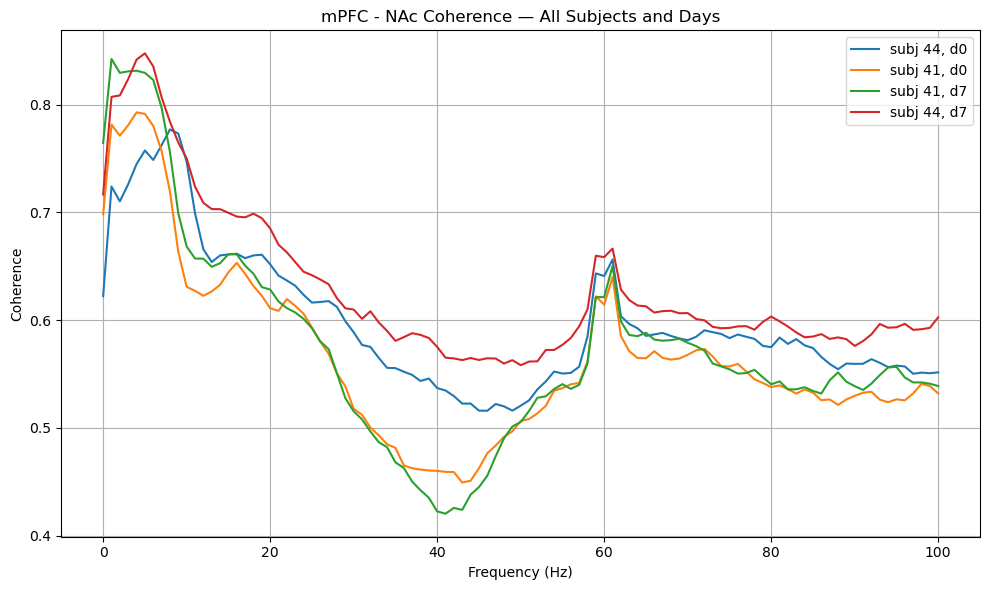

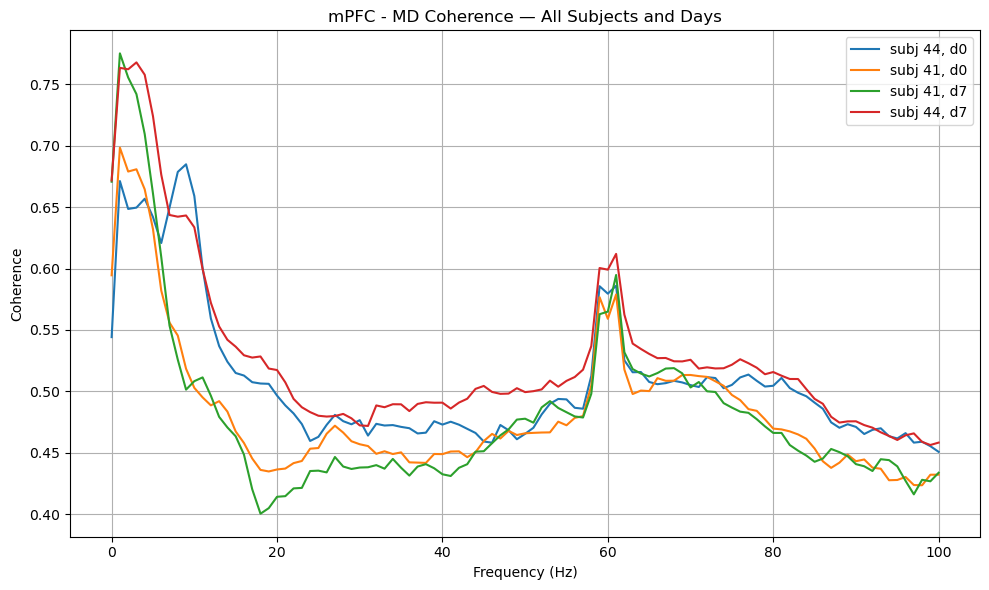

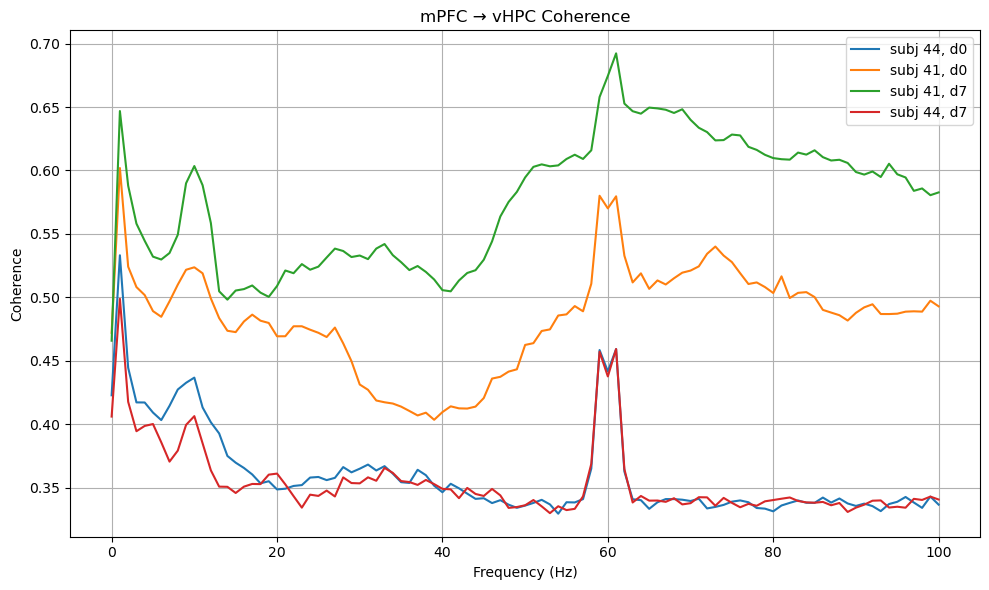

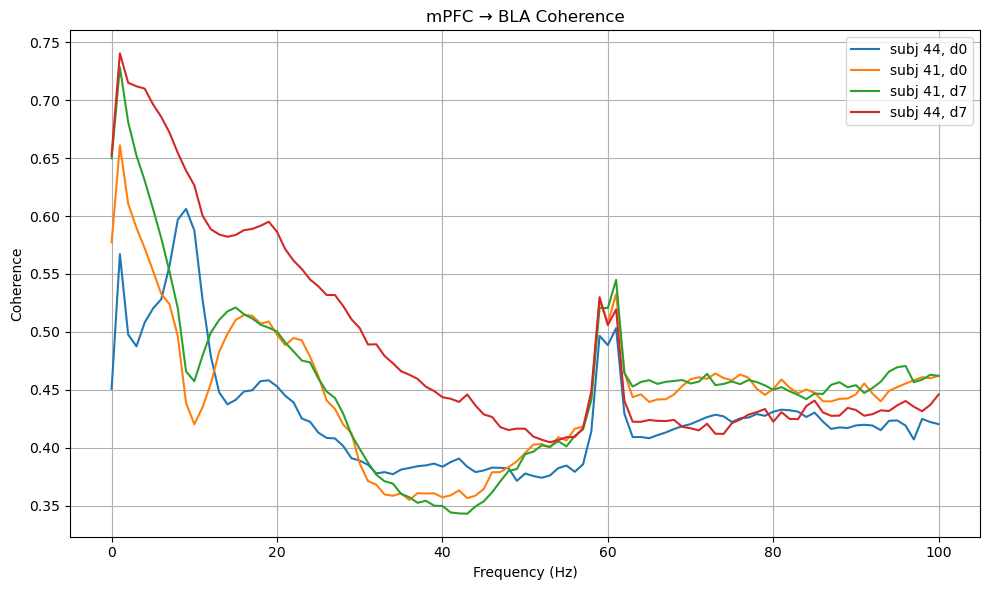

In [113]:
from pathlib import Path

def plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    curves = []
    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict

        # Skip if either region missing in dictionary
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]

        avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
        _, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            print(f"⚠️ Skipping {rec.name}: index ({from_idx}, {to_idx}) out of bounds for R={R}")
            continue

        subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]
        day = 'd0' if 'd0' in rec.name else 'd7' if 'd7' in rec.name else 'UNK'

        coh_curve = avg_coh[:, from_idx, to_idx]

        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        label = f"subj {subj}, {day}"
        curves.append((label, freqs_plot, coh_plot))

    if not curves:
        print(f"⚠️ No valid data to plot for {region_from} - {region_to}")
        return

    # Plot
    plt.figure(figsize=(10, 6))
    for label, freqs, coh in curves:
        plt.plot(freqs, coh, label=label)
    plt.title(title if title else f"{region_from} - {region_to} Coherence — All Subjects and Days")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Coherence")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save to file
    if save_path:
        # Ensure directory exists
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


# Example usage
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='MD', # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='vHPC', title="mPFC → vHPC Coherence"
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='BLA', title="mPFC → BLA Coherence"
)

/scratch/local/14225831/ipykernel_3256897/167852665.py:22: RuntimeWarning: Mean of empty slice
  avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
/scratch/local/14225831/ipykernel_3256897/167852665.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(subjects))  # or 'Set1', 'tab20', etc.


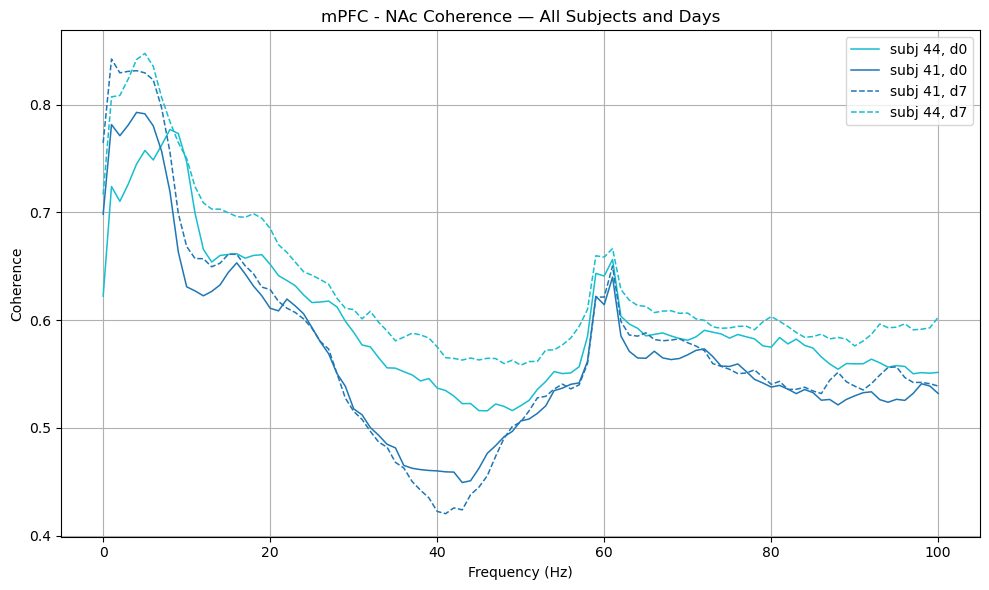

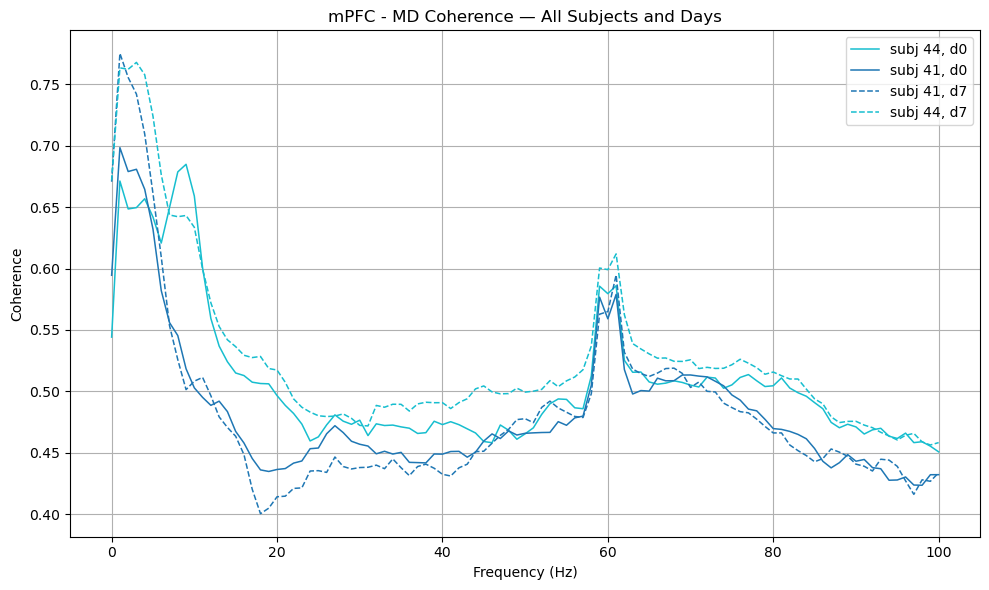

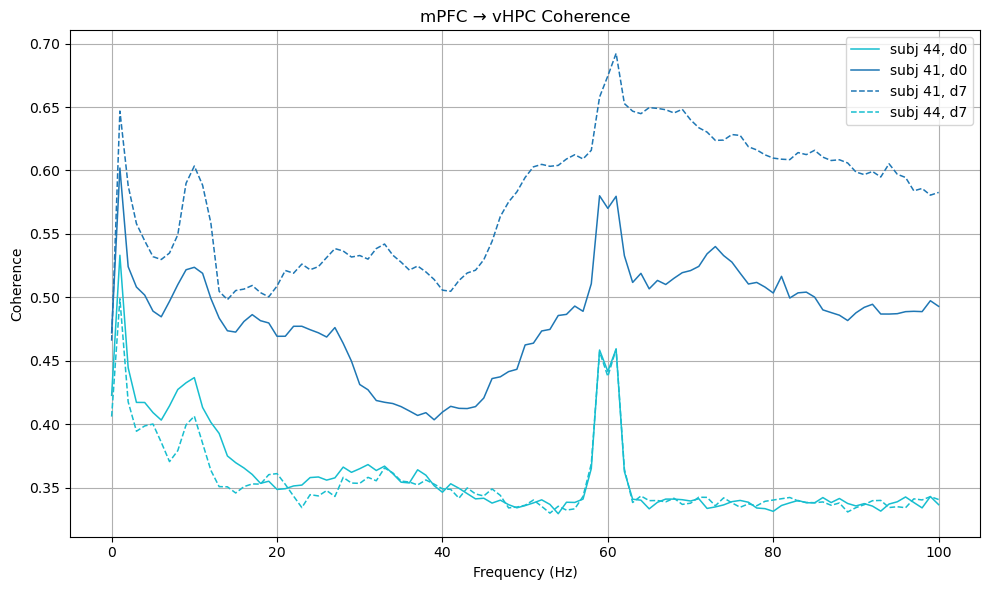

In [112]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict

def plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', 
    freq_limit=100, title=None, save_path=None
):
    curves = []
    for rec in lfp_collection.recordings:
        region_dict = rec.brain_region_dict

        # Skip if either region missing in dictionary
        if not all(region in region_dict for region in [region_from, region_to]):
            continue

        from_idx = region_dict[region_from]
        to_idx = region_dict[region_to]

        avg_coh = np.nanmean(rec.coherence, axis=0)  # (F, R, R)
        _, R, _ = avg_coh.shape
        if from_idx >= R or to_idx >= R:
            print(f"⚠️ Skipping {rec.name}: index ({from_idx}, {to_idx}) out of bounds for R={R}")
            continue

        subj = rec.subject if hasattr(rec, "subject") else rec.name.split('_')[0]
        day = 'd0' if 'd0' in rec.name else 'd7' if 'd7' in rec.name else 'UNK'

        coh_curve = avg_coh[:, from_idx, to_idx]

        freqs = rec.frequencies
        freq_mask = freqs <= freq_limit
        freqs_plot = freqs[freq_mask]
        coh_plot = coh_curve[freq_mask]

        label = f"subj {subj}, {day}"
        curves.append((label, freqs_plot, coh_plot))

    if not curves:
        print(f"⚠️ No valid data to plot for {region_from} - {region_to}")
        return


    # Extract unique subject IDs
    subjects = sorted(set(label.split(',')[0].split()[-1] for label, _, _ in curves))
    
    # Generate color map
    cmap = cm.get_cmap('tab10', len(subjects))  # or 'Set1', 'tab20', etc.
    subject_colors = {subj: cmap(i) for i, subj in enumerate(subjects)}

    plt.figure(figsize=(10, 6))

    for label, freqs, coh in curves:
        subj = label.split(',')[0].split()[-1]
        day = label.split(',')[1].strip()

        linestyle = '--' if day == 'd7' else '-'
        color = subject_colors[subj]

        plt.plot(freqs, coh, label=label, linewidth=1.1, linestyle=linestyle, color=color)

    plt.title(title if title else f"{region_from} - {region_to} Coherence — All Subjects and Days")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Coherence")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    # Save or show the plot
    if save_path:
        save_dir = Path(save_path)
        save_dir.mkdir(parents=True, exist_ok=True)
        filename = f"{region_from}_to_{region_to}_color_same.png"
        full_path = save_dir / filename
        plt.savefig(full_path)
        plt.close()
        print(f"✅ Saved: {full_path}")
    else:
        plt.show()


# Example usage
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='NAc', # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='MD', # save_path=r'/home/t.heeps/blue_npadillacoreano/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/npadillacoreano/t.heeps/rehouse_code/coherence_plots/plots/'
)
plot_coherence_between_regions(
    lfp_collection, region_from='mPFC', region_to='vHPC', title="mPFC → vHPC Coherence"
)

### Filtering coherence data to only include coherence during the tone

In [22]:
!jupyter nbconvert --to script coherence_41_44.ipynb

[NbConvertApp] Converting notebook coherence_41_44.ipynb to script
[NbConvertApp] Writing 7972 bytes to coherence_41_44.py


In [54]:
print(dir(d0_44))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__interpolate_coherence_granger__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_get_selected_traces', '_read_trodes', 'brain_region_dict', 'calculate_all', 'calculate_coherence', 'calculate_granger_causality', 'calculate_power', 'channel_dict', 'coherence', 'connectivity', 'elec_noise_freq', 'event_dict', 'exclude_regions', 'export_trodes_timestamps', 'find_start_recording_time', 'first_timestamp', 'frequencies', 'get_all_channels', 'halfbandwidth', 'interpolate_coherence', 'interpolate_granger', 'interpolate_power', 'load_rec_from_h5', 'max_freq', 'merged_rec_path', 'min_freq', 'name', 'plot_all_channels', 'plot_to_find_threshold', 'preprocess', 'rec_length', 'rec_path', 'resample_rate'

In [55]:
d0_44.event_dict

{'anogenital sniffing': array([[ 606.667,  617.8  ],
        [ 607.6  ,  611.933],
        [ 618.333,  626.467],
        [ 627.267,  629.533],
        [ 630.067,  633.467],
        [ 635.133,  636.467],
        [ 643.2  ,  643.532],
        [ 648.067,  648.4  ],
        [ 650.267,  657.533],
        [ 650.467,  653.667],
        [ 659.733,  661.399],
        [ 663.667,  663.933],
        [ 668.533,  668.866],
        [ 679.667,  681.666],
        [ 689.4  ,  692.6  ],
        [ 689.467,  691.132],
        [ 692.333,  702.467],
        [ 693.267,  694.467],
        [ 701.267,  701.6  ],
        [ 706.   ,  706.8  ],
        [ 745.333,  745.866],
        [ 746.667,  748.199],
        [ 749.   ,  754.8  ],
        [ 798.067,  801.132],
        [ 811.8  ,  812.067],
        [ 871.733,  873.267],
        [ 876.867,  877.533],
        [ 878.267,  880.533],
        [ 882.067,  889.532],
        [ 890.933,  892.599],
        [ 894.867,  895.266],
        [ 928.133,  929.199],
        [1007.4  

In [48]:
!jupyter nbconvert --to script coherence_41_44.ipynb

[NbConvertApp] Converting notebook coherence_41_44.ipynb to script
[NbConvertApp] Writing 3288 bytes to coherence_41_44.py
